In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import os
import numpy as np

In [50]:
# ================== 0. 创建保存目录 ==================
os.makedirs("loss", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# ================== 1. 数据加载 ==================
data = pd.read_csv("data/data-1-vae.csv")
positions = data[["X", "Y"]].values 
energies = data["Potential_Energy"].values.reshape(-1, 1)

# 转换为PyTorch张量
tensor_positions = torch.FloatTensor(positions)
tensor_energies = torch.FloatTensor(energies)
dataset = TensorDataset(tensor_positions, tensor_energies)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# ================== 2. 定义VAE模型 ==================
class b2dVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=8):
        super(b2dVAE, self).__init__()
        # 编码器
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        self.fc_mean = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        
        # 解码器
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mean(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar
    
def potential_energy(x, y):
    # 盆底1参数 (左下方)
    A1 = 5.0
    a1, b1, c1 = 0.3, 0.5, 0.2
    x1, y1 = 1.0, 2.0
    
    # 盆底2参数 (右上方)
    A2 = 4.5
    a2, b2, c2 = 0.4, 0.3, -0.3
    x2, y2 = 4.0, 3.5
    
    # 中央势垒参数
    B = 3.0
    x0, y0 = 3, 3.0
    sigma_x, sigma_y = 2.0, 1.5
    
    # 计算势能（使用PyTorch操作）
    well1 = -A1 * torch.exp(-a1*(x-x1)**2 - b1*(y-y1)**2 - c1*(x-x1)*(y-y1))
    well2 = -A2 * torch.exp(-a2*(x-x2)**2 - b2*(y-y2)**2 - c2*(x-x2)*(y-y2))
    barrier = B * torch.exp(-(x-x0)**4/sigma_x**4 - (y-y0)**4/sigma_y**4)
    
    return well1 + well2 + barrier

# ================== 3. 定义损失函数 ==================
def loss_function(recon_x, x, energy, mu, logvar,recon_weight=2.8, energy_weight=0.001, kl_weight=0.5):
    recon_loss = nn.MSELoss()(recon_x, x)
    
    with torch.no_grad():
        original_energy = energy.flatten()  # 将 [batch_size, 1] 转换为 [batch_size]
        recon_energy = potential_energy(recon_x[:,0], recon_x[:,1])
    
    energy_loss = nn.MSELoss()(recon_energy, original_energy)
    
    # KL散度
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = kl_loss / x.size(0)
    
    # 组合损失
    total_loss = (recon_weight * recon_loss + energy_weight * energy_loss + kl_weight * kl_loss)
    
    return total_loss, recon_loss, energy_loss, kl_loss

# ================== 4. 训练配置 ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = b2dVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_history = []

# ================== 5. 训练循环 ==================
num_epochs = 250
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_recon_loss = 0.0
    epoch_energy_loss = 0.0
    epoch_kl_loss = 0.0
    
    for batch in dataloader:
        x, e = batch[0].to(device), batch[1].to(device)
        recon_x, mu, logvar = model(x)

        total_loss, recon_loss, energy_loss, kl_loss = loss_function(recon_x, x, e, mu, logvar)
        
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        # 记录损失
        epoch_loss += total_loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_energy_loss += energy_loss.item()
        epoch_kl_loss += kl_loss.item()
    
    # 计算平均损失
    avg_loss = epoch_loss / len(dataloader)
    avg_recon = epoch_recon_loss / len(dataloader)
    avg_energy = epoch_energy_loss / len(dataloader)
    avg_kl = epoch_kl_loss / len(dataloader)
    
    loss_history.append((avg_loss, avg_recon, avg_energy, avg_kl))
    
    # 打印进度
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Total Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | Energy Loss: {avg_energy:.4f} | KL: {avg_kl:.4f}")
        print("-" * 50)
    
    with open("loss/m-vae-loss.txt", "w") as f:
        for loss_values in loss_history:
            f.write(f"{loss_values[0]}, {loss_values[1]}, {loss_values[2]}, {loss_values[3]}\n")

# ================== 6. 保存最终模型 ==================
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, "models/m-vae-b2d.pth")

Epoch [5/250] | Total Loss: 16.8128 | Recon: 3.8479 | Energy Loss: 3.1521 | KL: 12.0713
--------------------------------------------------
Epoch [10/250] | Total Loss: 8.6067 | Recon: 2.0085 | Energy Loss: 1.8474 | KL: 5.9621
--------------------------------------------------
Epoch [15/250] | Total Loss: 5.3214 | Recon: 0.7937 | Energy Loss: 1.1761 | KL: 6.1958
--------------------------------------------------
Epoch [20/250] | Total Loss: 4.3131 | Recon: 0.5783 | Energy Loss: 0.9547 | KL: 5.3860
--------------------------------------------------
Epoch [25/250] | Total Loss: 3.9568 | Recon: 0.5395 | Energy Loss: 1.0304 | KL: 4.8907
--------------------------------------------------
Epoch [30/250] | Total Loss: 3.5958 | Recon: 0.4497 | Energy Loss: 0.8726 | KL: 4.6716
--------------------------------------------------
Epoch [35/250] | Total Loss: 3.3941 | Recon: 0.4302 | Energy Loss: 0.8156 | KL: 4.3773
--------------------------------------------------
Epoch [40/250] | Total Loss: 3.11

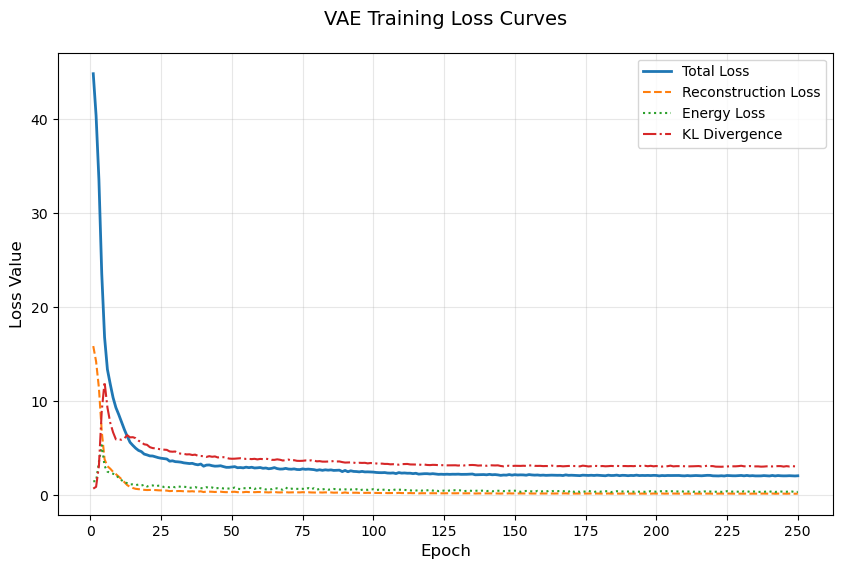

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 读取损失数据
loss_file = "loss/m-vae-loss.txt"
if not os.path.exists(loss_file):
    raise FileNotFoundError(f"Loss file not found at {loss_file}")

with open(loss_file, 'r') as f:
    lines = f.readlines()

# 解析数据
loss_data = []
for line in lines:
    parts = line.strip().split(',')
    if len(parts) == 4:  # 确保每行有4个值
        loss_data.append([float(x) for x in parts])

loss_data = np.array(loss_data)
epochs = np.arange(1, len(loss_data)+1)

# 2. 绘制损失曲线
plt.figure(figsize=(10, 6))

# 总损失
plt.plot(epochs, loss_data[:, 0], 
         label='Total Loss', 
         color='#1f77b4', 
         linewidth=2)

# 重构损失
plt.plot(epochs, loss_data[:, 1], 
         label='Reconstruction Loss', 
         color='#ff7f0e', 
         linestyle='--')

# 势能损失
plt.plot(epochs, loss_data[:, 2], 
         label='Energy Loss', 
         color='#2ca02c', 
         linestyle=':')

# KL损失
plt.plot(epochs, loss_data[:, 3], 
         label='KL Divergence', 
         color='#d62728', 
         linestyle='-.')

# 图形装饰
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.title('VAE Training Loss Curves', fontsize=14, pad=20)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# 调整坐标轴范围
max_epoch = len(epochs)
if max_epoch > 50:
    plt.xticks(np.arange(0, max_epoch+1, max_epoch//10))
else:
    plt.xticks(np.arange(0, max_epoch+1, 5))

# 保存图像
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/loss_curves.png", dpi=300, bbox_inches='tight')
plt.show()

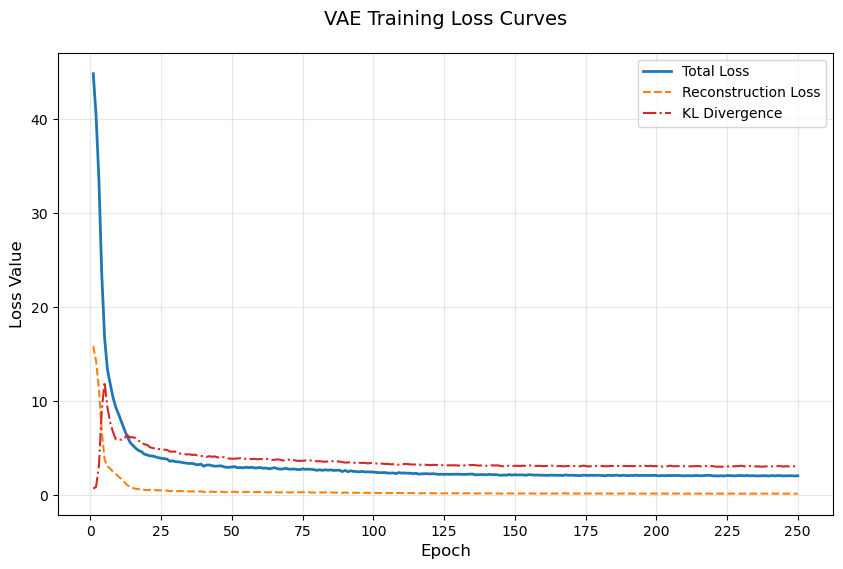

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 读取损失数据
loss_file = "loss/m-vae-loss.txt"
if not os.path.exists(loss_file):
    raise FileNotFoundError(f"Loss file not found at {loss_file}")

with open(loss_file, 'r') as f:
    lines = f.readlines()

# 解析数据
loss_data = []
for line in lines:
    parts = line.strip().split(',')
    if len(parts) == 4:  # 确保每行有4个值
        loss_data.append([float(x) for x in parts])

loss_data = np.array(loss_data)
epochs = np.arange(1, len(loss_data)+1)

# 2. 绘制损失曲线
plt.figure(figsize=(10, 6))

# 总损失
plt.plot(epochs, loss_data[:, 0], 
         label='Total Loss', 
         color='#1f77b4', 
         linewidth=2)

# 重构损失
plt.plot(epochs, loss_data[:, 1], 
         label='Reconstruction Loss', 
         color='#ff7f0e', 
         linestyle='--')

# # 势能损失
# plt.plot(epochs, loss_data[:, 2], 
#          label='Energy Loss', 
#          color='#2ca02c', 
#          linestyle=':')

# KL损失
plt.plot(epochs, loss_data[:, 3], 
         label='KL Divergence', 
         color='#d62728', 
         linestyle='-.')

# 图形装饰
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.title('VAE Training Loss Curves', fontsize=14, pad=20)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# 调整坐标轴范围
max_epoch = len(epochs)
if max_epoch > 50:
    plt.xticks(np.arange(0, max_epoch+1, max_epoch//10))
else:
    plt.xticks(np.arange(0, max_epoch+1, 5))

# 保存图像
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/loss_curves.png", dpi=300, bbox_inches='tight')
plt.show()

## Make sure no bias 


=== 测试点 [1.0, 1.0] ===
中心点: [0.9993 1.049 ]
X标准差: 0.3771
Y标准差: 0.4350

=== 测试点 [6.0, 1.0] ===
中心点: [6.0453 0.9793]
X标准差: 0.4599
Y标准差: 0.3415

=== 测试点 [3.0, 3.0] ===
中心点: [2.9734 2.9536]
X标准差: 0.5215
Y标准差: 0.4848

=== 测试点 [1.0, 5.0] ===
中心点: [1.0235 4.7978]
X标准差: 0.3563
Y标准差: 0.4029

=== 测试点 [6.0, 5.0] ===
中心点: [6.1311 4.7948]
X标准差: 0.4358
Y标准差: 0.3700


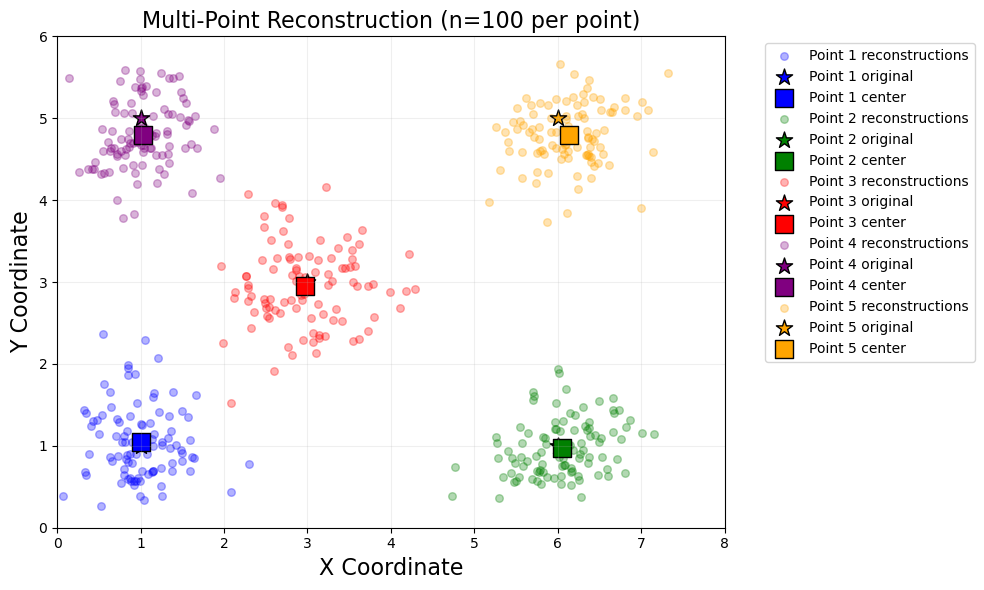

In [52]:
import torch
from utils import b2dVAE
import numpy as np
import matplotlib.pyplot as plt

# 1. 设置设备和模型路径
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_path = "models/m-vae-b2d.pth"

# 2. 加载模型函数
def load_b2dVAE(model_path, device):
    model = b2dVAE().to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

# 3. 加载训练好的模型
B2DVAE = load_b2dVAE(vae_path, device)

# 4. 重构函数（单点多次重构）
def reconstruct_point(model, point, n_reconstructions=100):
    with torch.no_grad():
        input_tensor = torch.FloatTensor(point).unsqueeze(0).to(device)
        mu, logvar = model.encode(input_tensor)
        
        reconstructions = []
        for _ in range(n_reconstructions):
            z = model.reparameterize(mu, logvar)
            recon = model.decode(z)
            reconstructions.append(recon.squeeze(0).cpu().numpy())
        
        center_point = np.mean(reconstructions, axis=0)
        std_dev = np.std(reconstructions, axis=0)
        
        return {
            'mu': mu.squeeze(0).cpu().numpy(),
            'logvar': logvar.squeeze(0).cpu().numpy(),
            'reconstructions': np.array(reconstructions),
            'center_point': center_point,
            'std_dev': std_dev
        }

# 5. 定义5个测试点（覆盖不同区域）
test_points = [
    [1.0, 1.0],    # 左下区域
    [6.0, 1.0],    # 右下区域
    [3.0, 3.0],    # 中心区域
    [1.0, 5.0],    # 左上区域 
    [6.0, 5.0]     # 右上区域
]
n_recon = 100  # 每个点的重构次数

# 6. 运行所有点的重构
all_results = []
for point in test_points:
    results = reconstruct_point(B2DVAE, point, n_recon)
    all_results.append(results)
    
    # 打印单个点结果
    print(f"\n=== 测试点 {point} ===")
    print(f"中心点: {results['center_point'].round(4)}")
    print(f"X标准差: {results['std_dev'][0]:.4f}")
    print(f"Y标准差: {results['std_dev'][1]:.4f}")

# 7. 综合可视化
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red', 'purple', 'orange']  # 每个点的颜色

# 绘制所有重构点
for i, (point, results) in enumerate(zip(test_points, all_results)):
    plt.scatter(results['reconstructions'][:,0], 
                results['reconstructions'][:,1],
                c=colors[i], alpha=0.3, s=30, 
                label=f'Point {i+1} reconstructions')
    
    # 标记原始点和中心点
    plt.scatter(point[0], point[1], 
                c=colors[i], s=150, marker='*', 
                edgecolor='black', linewidth=1,
                label=f'Point {i+1} original')
    plt.scatter(results['center_point'][0], results['center_point'][1],
                c=colors[i], s=150, marker='s', 
                edgecolor='black', linewidth=1,
                label=f'Point {i+1} center')

# 图形装饰
plt.xlabel('X Coordinate', fontsize=16)
plt.ylabel('Y Coordinate', fontsize=16)
plt.title(f'Multi-Point Reconstruction (n={n_recon} per point)', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.xlim(0, 8)
plt.ylim(0, 6)
plt.tight_layout()

# 保存图像
plt.savefig("figures/multi_point_reconstruction.tiff", dpi=300, bbox_inches='tight')
plt.show()